In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\ROG\Downloads\archive (6)\SampleSuperstore.csv")

# 🔹 1. Basic Data Exploration

 Load the dataset and show first 5 rows

In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


How many rows and columns?

In [5]:
df.shape

(9994, 13)

What are the top 5 most expensive products (based on sales)?

In [11]:
expensive_products = df.sort_values(by='Sales', ascending=False).head()

In [12]:
expensive_products

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
2697,Standard Class,Home Office,United States,Jacksonville,Florida,32216,South,Technology,Machines,22638.480,6,0.5,-1811.0784
6826,Standard Class,Corporate,United States,Lafayette,Indiana,47905,Central,Technology,Copiers,17499.950,5,0.0,8399.9760
8153,First Class,Consumer,United States,Seattle,Washington,98115,West,Technology,Copiers,13999.960,4,0.0,6719.9808
2623,First Class,Home Office,United States,New York City,New York,10024,East,Technology,Copiers,11199.968,4,0.2,3919.9888
4190,Standard Class,Consumer,United States,Newark,Delaware,19711,East,Technology,Copiers,10499.970,3,0.0,5039.9856


What are the data types for each column?

In [27]:
df.dtypes

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Check for missing values

In [22]:
mising_values = df.isnull().sum()

In [23]:
mising_values

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

# 2️⃣ Sales & Profit Analysism

What is the total sales?

In [30]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [31]:
total_sales = df['Sales'].sum()

In [32]:
total_sales

np.float64(2297200.8603)

In [34]:
total_profit = df['Profit'].sum()

In [36]:
total_profit

np.float64(286397.0217)

In [37]:
average_discount = df['Discount'].mean()

In [38]:
average_discount

np.float64(0.1562027216329798)

In [41]:
high_Sale_category = df.groupby('Category')['Sales'].max().reset_index()

In [42]:
high_Sale_category

,Category,Sales
0,Furniture,4416.174
1,Office Supplies,9892.740
2,Technology,22638.480


In [45]:
high_profit_category = df.groupby('Category')['Profit'].max().reset_index()

In [46]:
high_profit_category

,Category,Profit
0,Furniture,1013.127
1,Office Supplies,4946.370
2,Technology,8399.976


In [49]:
high_sales_sub_category = df.groupby('Sub-Category')['Sales'].max().reset_index().head()

In [50]:
high_sales_sub_category

,Sub-Category,Sales
0,Accessories,3347.370
1,Appliances,2625.120
2,Art,1113.024
3,Binders,9892.740
4,Bookcases,4404.900


In [51]:
high_lowest_sub_category = df.groupby('Sub-Category')['Profit'].min().reset_index().head()

In [52]:
high_lowest_sub_category

,Sub-Category,Profit
0,Accessories,-75.5958
1,Appliances,-1181.2824
2,Art,0.1533
3,Binders,-3701.8928
4,Bookcases,-1665.0522


In [57]:
cities_high_total_sales = df.groupby('City')['Sales'].sum().reset_index()

In [58]:
cities_high_total_sales

,City,Sales
0,Aberdeen,25.500
1,Abilene,1.392
2,Akron,2729.986
3,Albuquerque,2220.160
4,Alexandria,5519.570
...,...,...
526,Woonsocket,195.550
527,Yonkers,7657.666
528,York,817.978
529,Yucaipa,50.800


In [59]:
cities_high_total_sales.sort_values(by='Sales', ascending=False).head(10)

,City,Sales
329,New York City,256368.1610
266,Los Angeles,175851.3410
452,Seattle,119540.7420
438,San Francisco,112669.0920
374,Philadelphia,109077.0130
207,Houston,64504.7604
80,Chicago,48539.5410
437,San Diego,47521.0290
216,Jacksonville,44713.1830
464,Springfield,43054.3420


In [60]:
most_profit_state = df.groupby('State')['Profit'].max().reset_index()

In [61]:
most_profit_state

,State,Profit
0,Alabama,1459.2000
1,Arizona,211.4955
2,Arkansas,843.1706
3,California,1906.4850
4,Colorado,247.9960
5,Connecticut,294.6710
6,Delaware,5039.9856
7,District of Columbia,648.5624
8,Florida,327.5922
9,Georgia,3177.4750


In [66]:
most_profit_state.sort_values(by='Profit', ascending=False).head()

,State,Profit
12,Indiana,8399.9760
45,Washington,6719.9808
6,Delaware,5039.9856
20,Michigan,4946.3700
21,Minnesota,4630.4755


In [64]:
most_profit_state.max().reset_index()

,index,0
0,State,Wyoming
1,Profit,8399.976


In [70]:
highest_loss = df.groupby('State')['Profit'].min().reset_index().head()

In [71]:
highest_loss

,State,Profit
0,Alabama,0.0000
1,Arizona,-814.4832
2,Arkansas,1.4190
3,California,-325.5720
4,Colorado,-3399.9800


In [72]:
highest_loss.sort_values(by='Profit').head(1)

,State,Profit
4,Colorado,-3399.98


# 3️⃣ Regional Analysis

In [73]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [74]:
total_sales_by_region = df.groupby('Region')['Sales'].sum().reset_index()

In [75]:
total_sales_by_region

,Region,Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


In [76]:
total_profit_by_region = df.groupby('Region')['Profit'].sum().reset_index()

In [77]:
total_profit_by_region

,Region,Profit
0,Central,39706.3625
1,East,91522.7800
2,South,46749.4303
3,West,108418.4489


In [84]:
avg_highest_discount = df.groupby('Region')['Discount'].mean().reset_index()

In [85]:
avg_highest_discount

,Region,Discount
0,Central,0.240353
1,East,0.145365
2,South,0.147253
3,West,0.109335


In [86]:
highest_avg_discount = avg_highest_discount.sort_values(by='Discount', ascending=False).head(1)

In [87]:
highest_avg_discount

,Region,Discount
0,Central,0.240353


In [90]:
highest_sales = df.groupby('Region')['Sales'].mean().reset_index()

In [91]:
highest_sales

,Region,Sales
0,Central,215.772661
1,East,238.336110
2,South,241.803645
3,West,226.493233


In [92]:
highest_sales.sort_values(by='Sales', ascending=False).head(1)

,Region,Sales
2,South,241.803645


# Bar Chart

In [93]:
profit_by_region = df.groupby('Region')['Profit'].sum().reset_index()

In [94]:
profit_by_region

,Region,Profit
0,Central,39706.3625
1,East,91522.7800
2,South,46749.4303
3,West,108418.4489


([0, 1, 2, 3],
 [Text(0, 0, 'Central'),
  Text(1, 0, 'East'),
  Text(2, 0, 'South'),
  Text(3, 0, 'West')])

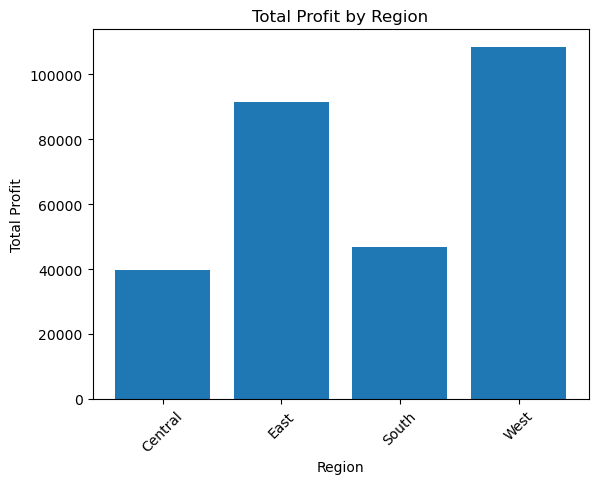

In [100]:
plt.bar(profit_by_region['Region'], profit_by_region['Profit'])
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=45) 

In [101]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [102]:
profit_by_category = df.groupby('Category')['Sales'].sum().reset_index()

In [103]:
profit_by_category

,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


([0, 1, 2],
 [Text(0, 0, 'Furniture'),
  Text(1, 0, 'Office Supplies'),
  Text(2, 0, 'Technology')])

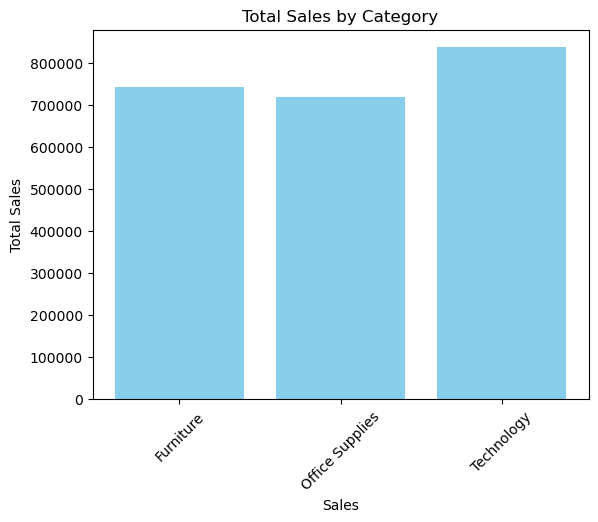

In [107]:
plt.bar(profit_by_category['Category'],profit_by_category['Sales'], color='skyblue' )
plt.title('Total Sales by Category')
plt.xlabel('Sales')
plt.ylabel('Total Sales')
plt.xticks(rotation=45) 

# 4️⃣ Customer Segment Insights

In [109]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [111]:
df.groupby('Segment')['Quantity'].count().reset_index()

,Segment,Quantity
0,Consumer,5191
1,Corporate,3020
2,Home Office,1783


In [116]:
sales = df.groupby('Segment')['Sales'].sum().reset_index()

In [117]:
sales.sort_values(by='Sales', ascending=False).head(1)

,Segment,Sales
0,Consumer,1161401.345


In [118]:
segment_most_profit = df.groupby('Segment')['Profit'].sum().reset_index()

In [119]:
segment_most_profit

,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


In [121]:
segment_most_profit.sort_values(by='Profit', ascending=False).head(1)

,Segment,Profit
0,Consumer,134119.2092


In [122]:
segment_average_discount = df.groupby('Segment')['Discount'].mean().reset_index()

In [123]:
segment_average_discount

,Segment,Discount
0,Consumer,0.158141
1,Corporate,0.158228
2,Home Office,0.147128


# 5️⃣ Shipping Analysis

In [126]:
order_ship = df.groupby('Ship Mode')['Quantity'].count()

In [125]:
order_ship


Ship Mode
First Class       1538
Same Day           543
Second Class      1945
Standard Class    5968
Name: Quantity, dtype: int64

In [132]:
comparing = df.groupby('Ship Mode')['Profit'].sum()

In [133]:
comparing

Ship Mode
First Class        48969.8399
Same Day           15891.7589
Second Class       57446.6354
Standard Class    164088.7875
Name: Profit, dtype: float64

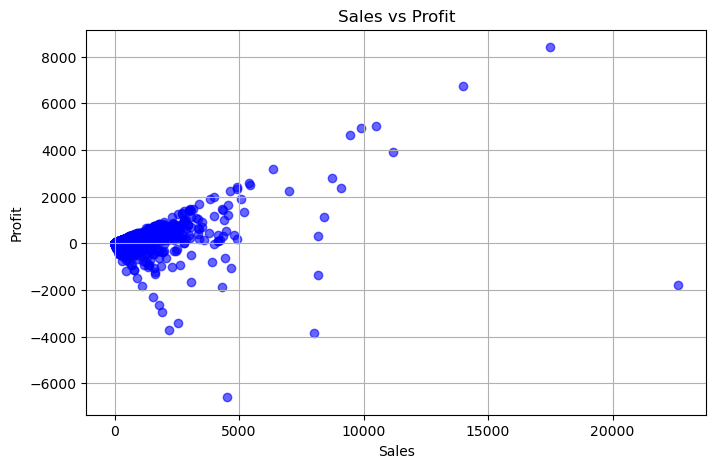

In [142]:

plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'], color='blue', alpha=0.6)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True)
plt.show()